# 실습 2. SVC 분류

Breast Cancer 데이터와 Moons 데이터를 사용해 SVC의 핵심 흐름을 연습함.

- `StandardScaler`로 feature 스케일을 맞춤.
- 선형 SVC를 학습하고 accuracy, classification report를 확인함.
- `C` 값 변화에 따라 score와 support vector 개수가 어떻게 달라지는지 비교함.
- RBF 커널에서 `gamma` 값 변화에 따른 성능 차이를 확인함.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

cancer = load_breast_cancer(as_frame=True)
cancer_df = cancer.frame.copy()

cancer_X = cancer_df[cancer.feature_names]
cancer_y = cancer_df['target']

print(cancer_df.shape)
print(cancer.target_names)
display(cancer_df.head())


(569, 31)
['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 문제 1. 학습/평가 데이터 분리와 스케일링

`cancer_X`, `cancer_y`를 학습/평가 데이터로 나누고 `StandardScaler`를 적용함.

힌트:
- `train_test_split()`
- `stratify=cancer_y`
- `scaler.fit_transform(X_train)`
- `scaler.transform(X_test)`

### 실행 결과
```text
X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)
```


In [6]:
cancer_X = cancer_df[cancer.feature_names]
cancer_y = cancer_df['target']

cancer_X_train, cancer_X_test, cancer_y_train, cancer_y_test = train_test_split(
    cancer_X, cancer_y, random_state=4, stratify=cancer_y
)

## 문제 2. 선형 SVC 모델 학습과 평가

`kernel='linear'`인 SVC 모델을 만들고 학습셋/평가셋 accuracy와 classification report를 확인함.

힌트:
- `SVC(kernel='linear', C=1.0)`
- `fit()`
- `score()`
- `classification_report()`

### 실행 결과
```text
학습셋 accuracy: 0.9912087912087912
평가셋 accuracy: 0.9736842105263158

              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114
```


In [7]:
scaler = StandardScaler()
cancer_X_train_scaled = scaler.fit_transform(cancer_X_train)
cancer_X_test_scaled = scaler.transform(cancer_X_test)

# SVC 모델 생성 및 학습
cancer_svc = SVC(kernel='linear', C=1.0)
cancer_svc.fit(cancer_X_train_scaled, cancer_y_train)

# 정확도 평가
print(f'학습셋 평가: {cancer_svc.score(cancer_X_train_scaled, cancer_y_train):.4f}')
print(f'평가셋 평가: {cancer_svc.score(cancer_X_test_scaled, cancer_y_test):.4f}')

# 예측
cancer_pred = cancer_svc.predict(cancer_X_test_scaled)

# 분류 성능 평가
print(classification_report(
    cancer_y_test,
    cancer_pred,
    target_names=cancer.target_names
))

학습셋 평가: 0.9930
평가셋 평가: 0.9720
              precision    recall  f1-score   support

   malignant       0.98      0.94      0.96        53
      benign       0.97      0.99      0.98        90

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143



## 문제 3. `C` 값 변화에 따른 성능 비교

`C` 후보를 바꿔가며 선형 SVC를 학습하고 학습셋/평가셋 accuracy, support vector 개수를 비교함.

힌트:
- `for c_value in [...]`
- `SVC(kernel='linear', C=c_value)`
- `len(model.support_)`

### 실행 결과
```text
C  train_accuracy  test_accuracy  support_vector_count
0    0.01        0.978022       0.964912                    99
1    0.10        0.984615       0.982456                    51
2    1.00        0.991209       0.973684                    32
3   10.00        0.991209       0.982456                    26
4  100.00        0.995604       0.973684                    26
```


In [13]:
results_c = []

c_lst = [0.01, 0.1, 1.0, 10.0, 100.0]

for c in c_lst:
    model = SVC(kernel='linear', C=c)
    model.fit(cancer_X_train_scaled, cancer_y_train)

    results_c.append({
        'C': c,
        'train_accuracy' : model.score(cancer_X_train_scaled, cancer_y_train),
        'test_accuracy' : model.score(cancer_X_test_scaled, cancer_y_test),
        'support_vector_count': len(model.support_)
    })

results_df = pd.DataFrame(results_c)
results_df

,C,train_accuracy,test_accuracy,support_vector_count
0,0.01,0.974178,0.972028,97
1,0.10,0.988263,0.972028,49
2,1.00,0.992958,0.972028,29
3,10.00,0.997653,0.965035,23
4,100.00,1.000000,0.965035,24


## 문제 4. `C` 변화 결과 시각화

문제 3에서 만든 `c_result_df`를 사용해 accuracy와 support vector 개수 변화를 그래프로 확인함.

### 실행 결과
```text
그래프 출력: Accuracy by C, Support vectors by C
```
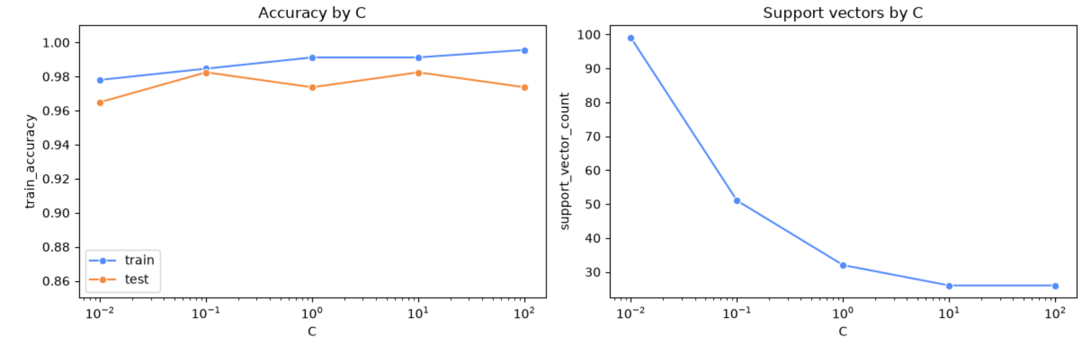


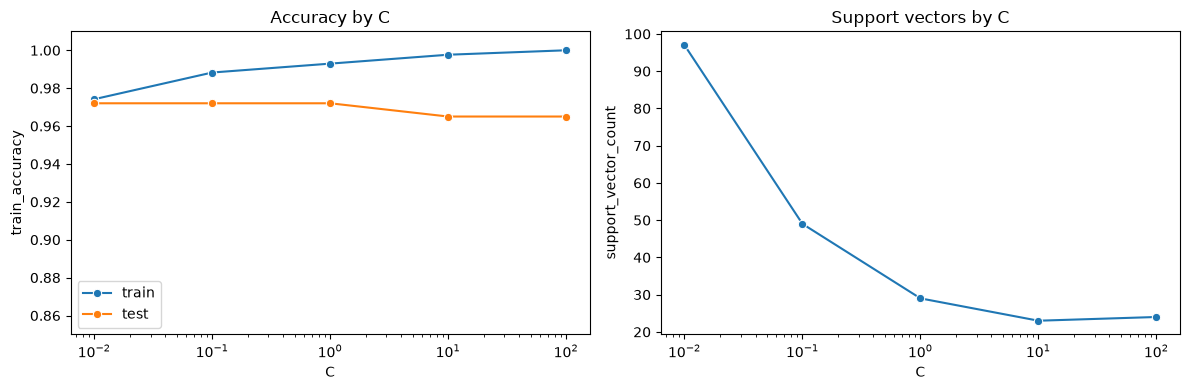

In [14]:
# 문제 풀이 후 실행: C 변화 결과 시각화

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=results_df, x='C', y='train_accuracy', marker='o', label='train', ax=axes[0])
sns.lineplot(data=results_df, x='C', y='test_accuracy', marker='o', label='test', ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_title('Accuracy by C')
axes[0].set_ylim(0.85, 1.01)

sns.lineplot(data=results_df, x='C', y='support_vector_count', marker='o', ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_title('Support vectors by C')

plt.tight_layout()
plt.show()


## 문제 5. RBF 커널과 `gamma` 값 비교

Moons 데이터는 직선 하나로 나누기 어려운 비선형 데이터임. RBF 커널 SVC로 `gamma` 값을 바꿔가며 성능을 비교함.

힌트:
- `make_moons()`
- `SVC(kernel='rbf', C=1.0, gamma=gamma_value)`
- `StandardScaler`

### 실행 결과
```text
gamma  train_accuracy  test_accuracy  support_vector_count
0    0.1        0.871111       0.840000                    85
1    1.0        0.915556       0.893333                    69
2   10.0        0.960000       0.920000                   132
3   30.0        0.977778       0.920000                   186
```


In [16]:
from sklearn.datasets import make_moons

moon_X, moon_y = make_moons(n_samples = 1000, noise=0.25, random_state=42)

moon_X_train, moon_X_test, moon_y_train, moon_y_test = train_test_split(moon_X, moon_y, random_state=4, test_size=0.2, stratify=moon_y)

moon_scaler = StandardScaler()

moon_X_train_scaled = moon_scaler.fit_transform(moon_X_train)
moon_X_test_scaled = moon_scaler.transform(moon_X_test)

In [17]:
results_gamma = []

gamma_lst = [0.1, 1.0, 10.0, 30.0]

for gamma in gamma_lst:

    model_gamma = SVC(kernel='rbf',C=1.0, gamma = gamma)

    model_gamma.fit(moon_X_train_scaled, moon_y_train)

    results_gamma.append({
        'gamma': gamma,
        'train_accuracy' : model_gamma.score(moon_X_train_scaled, moon_y_train),
        'test_accuracy' : model_gamma.score(moon_X_test_scaled, moon_y_test),
        'support_vector_count': len(model_gamma.support_)
    })

gamma_result_df = pd.DataFrame(results_gamma)
gamma_result_df

,gamma,train_accuracy,test_accuracy,support_vector_count
0,0.1,0.87125,0.915,281
1,1.0,0.94625,0.950,159
2,10.0,0.96375,0.950,288
3,30.0,0.96375,0.950,463


## 문제 6. `gamma` 변화 결과 시각화

`gamma_result_df`를 사용해 `gamma` 값에 따른 학습셋/평가셋 accuracy 변화를 그래프로 확인함.

### 실행 결과
```text
그래프 출력: RBF SVC accuracy by gamma
```

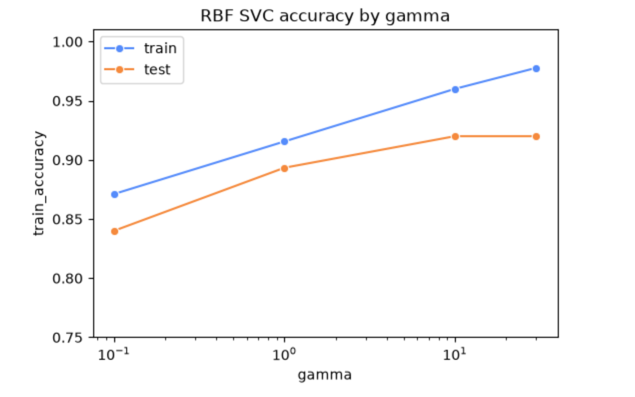

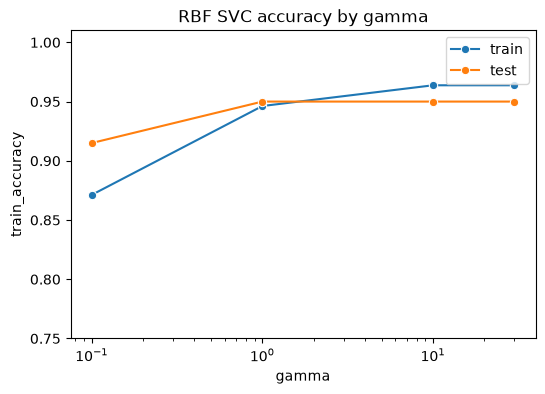

In [19]:
# 문제 풀이 후 실행: gamma 변화 결과 시각화

plt.figure(figsize=(6, 4))
sns.lineplot(data=gamma_result_df, x='gamma', y='train_accuracy', marker='o', label='train')
sns.lineplot(data=gamma_result_df, x='gamma', y='test_accuracy', marker='o', label='test')
plt.xscale('log')
plt.ylim(0.75, 1.01)
plt.title('RBF SVC accuracy by gamma')
plt.show()
